# Bai tap A8 — Phan loai Loi Be mat Thep (NEU)

**Bai 1:** CNN tu dau | **Bai 2:** ResNet18 Transfer | **Bai 3:** Confusion Matrix


## Cell 1 — Import & Config


In [6]:
# =====================================================================
# 1. HỆ THỐNG & PYTORCH CỐT LÕI (CORE DEEP LEARNING)
# =====================================================================
import os                          # Tương tác hệ điều hành (thao tác đường dẫn file, kiểm tra thư mục)
import torch                       # Thư viện Deep Learning cốt lõi: xử lý Tensor tính toán trên CPU/GPU
import torch.nn as nn              # Chứa các lớp tầng mạng nơ-ron (Conv2d, Linear, BatchNorm, Loss function...)
import torch.optim as optim        # Chứa các thuật toán tối ưu hóa cập nhật trọng số (Adam, SGD, AdamW...)

# =====================================================================
# 2. XỬ LÝ & NẠP DỮ LIỆU (DATASET & DATALOADER)
# =====================================================================
from torch.utils.data import DataLoader, random_split   # DataLoader: nạp batch, shuffle; random_split: chia tập train/val
from torchvision import datasets, transforms            # datasets: bộ dữ liệu mẫu; transforms: tăng cường & chuẩn hóa ảnh
from torchvision.datasets import ImageFolder            # Tự động nạp dữ liệu phân loại từ cấu trúc thư mục 'root/class/img.jpg'

# =====================================================================
# 3. MÔ HÌNH HỌC CHUYỂN GIAO (TRANSFER LEARNING)
# =====================================================================
from torchvision.models import resnet18, ResNet18_Weights  # resnet18: kiến trúc ResNet-18; ResNet18_Weights: trọng số pre-trained ImageNet

# =====================================================================
# 4. TÍNH TOÁN SỐ HỌC & TRỰC QUAN HÓA (VISUALIZATION)
# =====================================================================
import numpy as np                 # Thao tác mảng số học nhiều chiều, ma trận toán học
import matplotlib.pyplot as plt    # Vẽ biểu đồ huấn luyện (Loss/Accuracy) và hiển thị hình ảnh mẫu
import seaborn as sns              # Trực quan hóa dữ liệu thống kê (vẽ heatmap ma trận nhầm lẫn)

# =====================================================================
# 5. ĐÁNH GIÁ MÔ HÌNH (EVALUATION METRICS)
# =====================================================================
from sklearn.metrics import confusion_matrix, classification_report  # confusion_matrix: ma trận nhầm lẫn; classification_report: Precision/Recall/F1-score

CONFIG = {
    "data_dir" : r"d:\ai_foundation\ComputerVision\phase_2\A8\dataset\NEU-DET\train\images",
    "img_size" : (224, 224),
    "batch_size": 32,
    "lr": 1e-3,
    "epochs": 10,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
print(f"PyTorch: {torch.__version__} | Device: {CONFIG['device']}")


PyTorch: 2.5.1+cu121 | Device: cuda


## Cell 3 — Xem mau anh tung lop


1440 anh | Lop: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


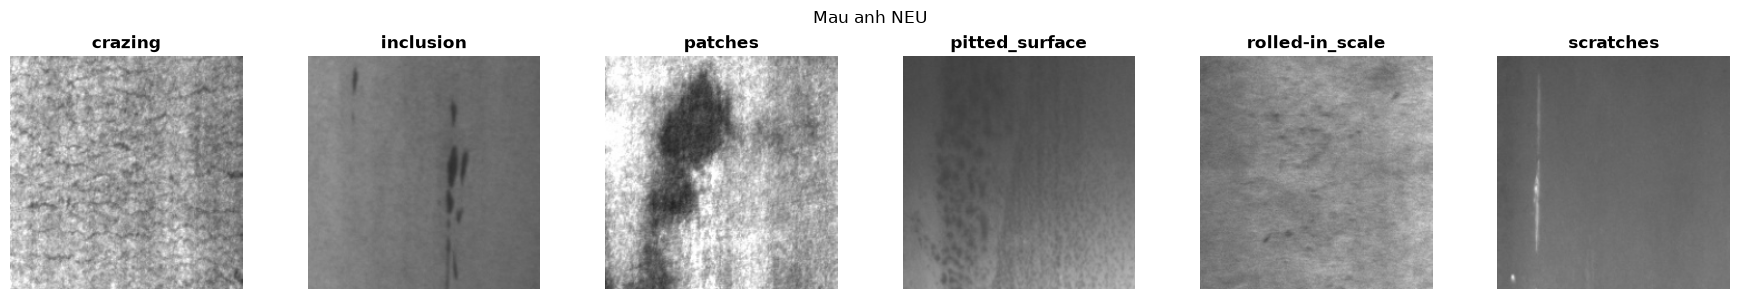

In [7]:
preview_ds = ImageFolder(
    root=CONFIG["data_dir"],
    transform=transforms.Compose([transforms.Resize(CONFIG['img_size']), transforms.ToTensor()]))
class_names = preview_ds.classes
num_classes = len(class_names)
print(f"{len(preview_ds)} anh | Lop: {class_names}")

seen = {}
for img_t, lbl in preview_ds:
    if lbl not in seen: seen[lbl] = img_t
    if len(seen) == num_classes: break

fig, axes = plt.subplots(1, num_classes, figsize=(3*num_classes, 3))
for i, (lbl, img_t) in enumerate(sorted(seen.items())):
    # PyTorch luu [C,H,W] | matplotlib can [H,W,C] --> dung .permute(1,2,0)
    axes[i].imshow(img_t.permute(1,2,0).numpy())
    axes[i].set_title(class_names[lbl], fontweight="bold")
    axes[i].axis("off")
plt.suptitle("Mau anh NEU"); plt.tight_layout(); plt.show()


## Cell 4 — DataLoader

Doi `USE_AUGMENTATION = True` de chay Bai 1 buoc 3 (so sanh overfit).


In [8]:
USE_AUGMENTATION = False  # True = Bài 1 bước 3 (thử nghiệm Data Augmentation)

# Bộ thông số chuẩn hóa ImageNet
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Transform cơ bản cho Validation (chỉ Resize & Chuẩn hóa, KHÔNG xoay lật ảnh)
base_tf = transforms.Compose([
    transforms.Resize(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transform tăng cường cho Train (Random Flip, Rotation, ColorJitter)
aug_tf = transforms.Compose([
    transforms.Resize(CONFIG["img_size"]),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Lựa chọn transform cho tập huấn luyện
train_tf = aug_tf if USE_AUGMENTATION else base_tf

# =====================================================================
# TAKE NOTE: CÁCH CHIA TẬP TRAIN / VAL ĐÚNG CHUẨN TRONG PYTORCH
# ---------------------------------------------------------------------
# [LỖI TRƯỚC ĐÂY]:
#    full_ds = ImageFolder(..., transform=train_tf)
#    tr_set, vl_set = random_split(full_ds, ...)
#    vl_set.dataset.transform = base_tf
# => LỖI: tr_set và vl_set chỉ là Subset trỏ chung vào 1 object full_ds.
#    Khi gán vl_set.dataset.transform, nó đổi luôn transform của cả tr_set!
#
# [GIẢI PHÁP ĐÚNG]:
#    1. Tạo 2 object ImageFolder độc lập (1 cho Train, 1 cho Val).
#    2. Dùng random_split chia danh sách chỉ số (indices) cố định seed 42.
#    3. Dùng Subset bọc riêng từng dataset -> Hoàn toàn tách biệt bộ nhớ!
# =====================================================================
from torch.utils.data import Subset

# 1. Tạo 2 Dataset độc lập với 2 bộ transform riêng biệt
train_ds = ImageFolder(root=CONFIG["data_dir"], transform=train_tf)
val_ds   = ImageFolder(root=CONFIG["data_dir"], transform=base_tf)

# 2. Tính số lượng mẫu (80% train, 20% val)
tr_n = int(0.8 * len(train_ds))
vl_n = len(train_ds) - tr_n

# 3. Chia danh sách chỉ số (indices) với seed 42 cố định
generator = torch.Generator().manual_seed(42)
tr_indices, vl_indices = random_split(range(len(train_ds)), [tr_n, vl_n], generator=generator)

# 4. Trích xuất 2 tập con độc lập trong bộ nhớ
tr_set = Subset(train_ds, tr_indices)  # Luôn giữ train_tf (có Augmentation nếu bật)
vl_set = Subset(val_ds, vl_indices)    # Luôn giữ base_tf (không có Augmentation)

# 5. Khởi tạo DataLoader - Nạp Batch, Shuffle
train_loader = DataLoader(tr_set, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=0)
val_loader   = DataLoader(vl_set, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"Train samples: {tr_n} | Val samples: {vl_n} | Augmentation: {USE_AUGMENTATION}")


Train samples: 1152 | Val samples: 288 | Augmentation: False


## Cell 5 — Dinh nghia CustomCNN (Bai 1)

**Quy uoc H x W x C (truc quan cho nguoi doc):**
```
Input    : 224 x 224 x  3
Conv1    : 224 x 224 x 16   (padding=1 giu nguyen H, W)
MaxPool1 : 112 x 112 x 16   (stride=2 chia doi H va W)
Conv2    : 112 x 112 x 32   (padding=1 giu nguyen H, W)
MaxPool2 :  56 x  56 x 32   (stride=2 chia doi H va W)
Flatten  :  56 * 56 * 32 = 100,352
Linear   :  N = so lop (6 voi NEU)
```
> **Luu y:** PyTorch luu tensor theo [B, C, H, W].
> Khi `print(tensor.shape)` ra `[32, 16, 224, 224]` thi C dung truoc H va W.
> Viet H x W x C o tren la quy uoc truc quan cho nguoi doc — khong phai thu tu tensor.


In [9]:
class CustomCNN(nn.Module):
    """CNN tu dau -- Bai 1 A8."""
    def __init__(self, nc=6):
        super().__init__()
        # H x W x C (quy uoc truc quan):
        # 224x224x3  -> Conv1  -> 224x224x16 -> MaxPool -> 112x112x16
        #            -> Conv2  -> 112x112x32 -> MaxPool ->  56x 56x32
        # Flatten: 56*56*32 = 100,352
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32*56*56,out_features=nc),
        )
    def forward(self, x): 
        return self.classifier(self.features(x))

def build_model(kind="custom_cnn", nc=6):
    if kind == "custom_cnn": return CustomCNN(nc)
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, nc)
    return m

# Kiem tra shape nhanh
device = torch.device(CONFIG["device"])
model  = build_model("custom_cnn", num_classes).to(device)
dummy  = torch.zeros(1, 3, 224, 224).to(device)  # [B, C, H, W]
feat   = model.features(dummy)
print("Input  [B,C,H,W]:", dummy.shape)  # [1,  3, 224, 224]
print("Feature[B,C,H,W]:", feat.shape)   # [1, 32,  56,  56]
print("  H x W x C     :  56 x 56 x 32")
print("Output          :", model(dummy).shape)
print("Params:", sum(p.numel() for p in model.parameters()))


Input  [B,C,H,W]: torch.Size([1, 3, 224, 224])
Feature[B,C,H,W]: torch.Size([1, 32, 56, 56])
  H x W x C     :  56 x 56 x 32
Output          : torch.Size([1, 6])
Params: 607206


## Cell 6 — Ham Train & Evaluate


In [ ]:
def train_one_epoch(model, loader, crit, opt, dev):
    model.train()
    ls = cr = tot = 0
    for x, y in loader:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad()
        o = model(x); l = crit(o, y)
        l.backward(); opt.step()
        ls  += l.item() * x.size(0)
        cr  += (o.argmax(1) == y).sum().item()
        tot += y.size(0)
    return ls/tot, cr/tot

@torch.no_grad()
def evaluate(model, loader, crit, dev):
    model.eval()
    ls = cr = tot = 0; ap, al = [], []
    for x, y in loader:
        x, y = x.to(dev), y.to(dev)
        o = model(x); l = crit(o, y)
        ls += l.item() * x.size(0)
        p  = o.argmax(1)
        cr  += (p == y).sum().item()
        tot += y.size(0)
        ap.extend(p.cpu().numpy())
        al.extend(y.cpu().numpy())
    return ls/tot, cr/tot, ap, al

print("Ham train va evaluate san sang.")


## Cell 7 — Training Loop


In [ ]:
MODEL_TYPE = "custom_cnn"  # doi "resnet18" cho Bai 2

model     = build_model(MODEL_TYPE, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
hist      = {k:[] for k in ["tl","vl","ta","va"]}

epochs_total = CONFIG["epochs"]
for ep in range(1, epochs_total+1):
    tl, ta       = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl, va, _, _ = evaluate(model, val_loader, criterion, device)
    hist["tl"].append(tl); hist["vl"].append(vl)
    hist["ta"].append(ta); hist["va"].append(va)
    print(f"[{ep:02d}/{epochs_total}] Train {tl:.4f}/{ta*100:.1f}%  Val {vl:.4f}/{va*100:.1f}%")
print("Huan luyen xong!")


## Cell 8 — Learning Curve


In [ ]:
ep_r = range(1, CONFIG["epochs"]+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep_r, hist["tl"], "o-",  label="Train")
ax1.plot(ep_r, hist["vl"], "s--", label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep_r, [a*100 for a in hist["ta"]], "o-",  label="Train")
ax2.plot(ep_r, [a*100 for a in hist["va"]], "s--", label="Val")
ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)
lbl = "Co Augmentation" if USE_AUGMENTATION else "Khong Augmentation"
fig.suptitle(f"{MODEL_TYPE} | {lbl}", fontweight="bold")
plt.tight_layout(); plt.show()
gap = hist["ta"][-1] - hist["va"][-1]
print(f"Overfit gap: {gap*100:.1f}%", "-> CO overfit!" if gap > 0.1 else "-> OK")


## Cell 9 — Confusion Matrix & Report (Bai 3)


In [ ]:
_, _, preds, labels_true = evaluate(model, val_loader, criterion, device)
cm = confusion_matrix(labels_true, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix — {MODEL_TYPE}", fontweight="bold")
plt.tight_layout(); plt.show()
print(classification_report(labels_true, preds, target_names=class_names))
print("Goi y: Lop nao co recall thap -> hay bo sot loi do nhat.")


## Cell 10 — Hien thi anh bi phan loai sai (Bai 3)


In [ ]:
wrong_imgs, wrong_true, wrong_pred = [], [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        pb   = model(imgs).argmax(1)
        mask = pb != labels
        if mask.any():
            wrong_imgs.extend(imgs[mask].cpu())
            wrong_true.extend(labels[mask].cpu().numpy())
            wrong_pred.extend(pb[mask].cpu().numpy())
        if len(wrong_imgs) >= 12: break

n = min(12, len(wrong_imgs))
if n == 0:
    print("Khong co anh nao bi phan loai sai!")
else:
    mt = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    st = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for i, ax in enumerate(axes.flat):
        if i >= n: ax.axis("off"); continue
        # Denormalize: [C,H,W] -> [H,W,C]
        img = (wrong_imgs[i]*st + mt).permute(1, 2, 0).numpy()
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(
            f"True:{class_names[wrong_true[i]]}\nPred:{class_names[wrong_pred[i]]}",
            fontsize=8, color="darkred")
        ax.axis("off")
    plt.suptitle("Anh phan loai sai", fontweight="bold")
    plt.tight_layout(); plt.show()
